<a href="https://colab.research.google.com/github/vnzhere/Python-/blob/main/Housing_marketing_intelligence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Housing Market Intelligence & Price Prediction System**

 A Complete Data Analysis & Machine Learning Project


**Goal:** Understand what drives housing prices and build a predictive model  

**Tools:** Python · Pandas · NumPy · Matplotlib · Scikit-learn  

**Author:** Vanzhere
**Date:** May 2026

**STEP 1: DATA LOADING**

1. Import libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%3f' % x)

print("Libraries imported!")

Libraries imported!


2. Load Dataset

In [5]:
import pandas as pd

url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"

df = pd.read_csv(url)

print("Dataset successfully loaded!")

Dataset successfully loaded!


**STEP 2: DATA UNDERSTANDING**

Why do we explore before we analyze data?


* Data is unknown which on jumping directly to analysis means driving without a map.
* These commands helps us in understanding, giving structure and plan our data cleaning strategy




In [6]:

df.head()
#gives column names, data types and sample values

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.006320,18.000000,2.310000,0,0.538000,6.575000,65.200000,4.090000,1,296,15.300000,396.900000,4.980000,24.000000
1,0.027310,0.000000,7.070000,0,0.469000,6.421000,78.900000,4.967100,2,242,17.800000,396.900000,9.140000,21.600000
2,0.027290,0.000000,7.070000,0,0.469000,7.185000,61.100000,4.967100,2,242,17.800000,392.830000,4.030000,34.700000
3,0.032370,0.000000,2.180000,0,0.458000,6.998000,45.800000,6.062200,3,222,18.700000,394.630000,2.940000,33.400000
4,0.069050,0.000000,2.180000,0,0.458000,7.147000,54.200000,6.062200,3,222,18.700000,396.900000,5.330000,36.200000


In [7]:
df.tail()
#tells us about data changes in the end (common in time ordered datasets)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
501,0.062630,0.000000,11.930000,0,0.573000,6.593000,69.100000,2.478600,1,273,21.000000,391.990000,9.670000,22.400000
502,0.045270,0.000000,11.930000,0,0.573000,6.120000,76.700000,2.287500,1,273,21.000000,396.900000,9.080000,20.600000
503,0.060760,0.000000,11.930000,0,0.573000,6.976000,91.000000,2.167500,1,273,21.000000,396.900000,5.640000,23.900000
504,0.109590,0.000000,11.930000,0,0.573000,6.794000,89.300000,2.388900,1,273,21.000000,393.450000,6.480000,22.000000
505,0.047410,0.000000,11.930000,0,0.573000,6.030000,80.800000,2.505000,1,273,21.000000,396.900000,7.880000,11.900000


In [8]:
#gives dimensions(r,c)
print(f"Shape: {df.shape}")

# means total no. of rows
# each row represents one house/ data obsv.
print(f"→ {df.shape[0]} rows (houses/observations)")

# total no. of columns
# represents attributes/feature of a house
print(f"→ {df.shape[1]} columns (features + 1 target)")

#returns colm names in form of a list
print(f"\nColumn names:\n{list(df.columns)}")

# "medv"-- is the value we want to predict/analyze (median home values in 1000s)
print(f"\nTarget variable: 'medv' (Median Home Value in $1000s)")

# remaining colms are feature variables, basically are inputs used to analyze/predict target variables
print(f"Feature variables: all other 13 columns")

Shape: (506, 14)
→ 506 rows (houses/observations)
→ 14 columns (features + 1 target)

Column names:
['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'b', 'lstat', 'medv']

Target variable: 'medv' (Median Home Value in $1000s)
Feature variables: all other 13 columns


In [9]:
# tells how many non-null values each column has
# datatype of each colm
# total memory usage

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [10]:
# 1 gives 8 statistical parameters for every numeric column

# if mean~median ---- data is normally distributed
# if very diff.---- data is skewed, outliers exist
df.describe()

# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# assuming df is your housing dataframe
# if not loaded yet:
# df = pd.read_csv('your_file.csv')

print("=== BASIC STATISTICS ===")
# print(df.describe())
# shows count, mean, std, min, max
# quartiles for every column


=== BASIC STATISTICS ===


## Observations from df.describe()

| Feature | Observation |
|---------|-------------|
| `crim` | Mean ≈ 3.6 but max ≈ 89 → heavily right-skewed, extreme outliers |
| `rm` | Mean ≈ 6.28 rooms → most houses are mid-sized |
| `medv` | Mean ≈ $22.5k, Max = $50k → some houses are capped at 50 (suspicious!) |
| `age` | Mean ≈ 68.6 → most housing stock is old (built pre-1940) |
| `lstat` | Ranges 1.7% to 38% → wide inequality across neighborhoods |

**STEP 3: DATA CLEANING**



* We clean data before we analyze
* Wrong datatypes cause errors in ml models
* outliers can distort averages and model weights
* duplicates inflate your datasets and bias results


In [11]:
# Handling missing value

# isnull-- returns T/F for each cell
missing = df.isnull().sum()

# .sum ----counts missing per column
# /len(df)---- converts to %
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count' : missing,
    'Missing %' : missing_pct.round(2)
})

print(missing_df)
print(f"\n Total missing values in dataset: {df.isnull().sum().sum()}")

         Missing Count  Missing %
crim                 0   0.000000
zn                   0   0.000000
indus                0   0.000000
chas                 0   0.000000
nox                  0   0.000000
rm                   0   0.000000
age                  0   0.000000
dis                  0   0.000000
rad                  0   0.000000
tax                  0   0.000000
ptratio              0   0.000000
b                    0   0.000000
lstat                0   0.000000
medv                 0   0.000000

 Total missing values in dataset: 0


In [12]:
#Duplicates --- same house counted twice

print("=== Duplicate Row Check===\n")


#df.duplicated-- checks all rows in a dataframe
# return true--- row duplicate
# returns false-- if not
#.sum()---counts total row values
duplicates = df.duplicated().sum()

#prints number of row
print(f"Number of Duplicates rows: {duplicates}")


#if exists
if duplicates>0:
  print("\nDuplicate rows:")

#keep=False ---- marks all the duplicate copies as true
# r1- original
# r2-Duplicate -----  both rows will be shown

#without keep=false--only repeated copy gets true

  display(df[df.duplicated(keep=False)])

else: #no duplicates exist
  print("No duplicates Found!")

=== Duplicate Row Check===

Number of Duplicates rows: 0
No duplicates Found!


In [13]:
#dataType verification

print("===Data Type Check===\n")

print(df.dtypes)

===Data Type Check===

crim       float64
zn         float64
indus      float64
chas         int64
nox        float64
rm         float64
age        float64
dis        float64
rad          int64
tax          int64
ptratio    float64
b          float64
lstat      float64
medv       float64
dtype: object


In [14]:
print("===Outlier detection using IQR method===\n")

# choosing column we want to analyze
# column = "crim"

for col in df.columns:

    # find 25%(Q1)
    Q1 = df[col].quantile(0.25)

    # find 75%(Q3)
    Q3 = df[col].quantile(0.75)

    # find IQR
    IQR = Q3 - Q1

    # cal lower and upper boundaries
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # find outliers(lower than lower limit or higher than upper limit)
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    # display the outliers rows
    print(f"Outliers found for column: {col}")
    display(outliers)


===Outlier detection using IQR method===

Outliers found for column: crim


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
367,13.522200,0.000000,18.100000,0,0.631000,3.863000,100.000000,1.510600,24,666,20.200000,131.420000,13.330000,23.100000
371,9.232300,0.000000,18.100000,0,0.631000,6.216000,100.000000,1.169100,24,666,20.200000,366.150000,9.530000,50.000000
373,11.108100,0.000000,18.100000,0,0.668000,4.906000,100.000000,1.174200,24,666,20.200000,396.900000,34.770000,13.800000
374,18.498200,0.000000,18.100000,0,0.668000,4.138000,100.000000,1.137000,24,666,20.200000,396.900000,37.970000,13.800000
375,19.609100,0.000000,18.100000,0,0.671000,7.313000,97.900000,1.316300,24,666,20.200000,396.900000,13.440000,15.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
468,15.575700,0.000000,18.100000,0,0.580000,5.926000,71.000000,2.908400,24,666,20.200000,368.740000,18.130000,19.100000
469,13.075100,0.000000,18.100000,0,0.580000,5.713000,56.700000,2.823700,24,666,20.200000,396.900000,14.760000,20.100000
477,15.023400,0.000000,18.100000,0,0.614000,5.304000,97.300000,2.100700,24,666,20.200000,349.480000,24.910000,12.000000
478,10.233000,0.000000,18.100000,0,0.614000,6.185000,96.700000,2.170500,24,666,20.200000,379.700000,18.030000,14.600000


Outliers found for column: zn


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
39,0.027630,75.000000,2.950000,0,0.428000,6.595000,21.800000,5.401100,3,252,18.300000,395.630000,4.320000,30.800000
40,0.033590,75.000000,2.950000,0,0.428000,7.024000,15.800000,5.401100,3,252,18.300000,395.620000,1.980000,34.900000
54,0.013600,75.000000,4.000000,0,0.410000,5.888000,47.600000,7.319700,3,469,21.100000,396.900000,14.800000,18.900000
55,0.013110,90.000000,1.220000,0,0.403000,7.249000,21.900000,8.696600,5,226,17.900000,395.930000,4.810000,35.400000
56,0.020550,85.000000,0.740000,0,0.410000,6.383000,35.700000,9.187600,2,313,17.300000,396.900000,5.770000,24.700000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
351,0.079500,60.000000,1.690000,0,0.411000,6.579000,35.900000,10.710300,4,411,18.300000,370.780000,5.490000,24.100000
352,0.072440,60.000000,1.690000,0,0.411000,5.884000,18.500000,10.710300,4,411,18.300000,392.330000,7.790000,18.600000
353,0.017090,90.000000,2.020000,0,0.410000,6.728000,36.100000,12.126500,5,187,17.000000,384.460000,4.500000,30.100000
354,0.043010,80.000000,1.910000,0,0.413000,5.663000,21.900000,10.585700,4,334,22.000000,382.800000,8.050000,18.200000


Outliers found for column: indus


...

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
18,0.802710,0.000000,8.140000,0,0.538000,5.456000,36.600000,3.796500,4,307,21.000000,288.990000,11.690000,20.200000
25,0.840540,0.000000,8.140000,0,0.538000,5.599000,85.700000,4.454600,4,307,21.000000,303.420000,16.510000,13.900000
27,0.955770,0.000000,8.140000,0,0.538000,6.047000,88.800000,4.453400,4,307,21.000000,306.380000,17.280000,14.800000
32,1.387990,0.000000,8.140000,0,0.538000,5.950000,82.000000,3.990000,4,307,21.000000,232.600000,27.710000,13.200000
34,1.612820,0.000000,8.140000,0,0.538000,6.096000,96.900000,3.759800,4,307,21.000000,248.310000,20.340000,13.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
466,3.774980,0.000000,18.100000,0,0.655000,5.952000,84.700000,2.871500,24,666,20.200000,22.010000,17.150000,19.000000
467,4.422280,0.000000,18.100000,0,0.584000,6.003000,94.500000,2.540300,24,666,20.200000,331.290000,21.320000,19.100000
475,6.393120,0.000000,18.100000,0,0.584000,6.162000,97.400000,2.206000,24,666,20.200000,302.760000,24.100000,13.300000
489,0.183370,0.000000,27.740000,0,0.609000,5.414000,98.300000,1.755400,4,711,20.100000,344.050000,23.970000,7.000000


Outliers found for column: lstat


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
141,1.628640,0.000000,21.890000,0,0.624000,5.019000,100.000000,1.439400,4,437,21.200000,396.900000,34.410000,14.400000
373,11.108100,0.000000,18.100000,0,0.668000,4.906000,100.000000,1.174200,24,666,20.200000,396.900000,34.770000,13.800000
374,18.498200,0.000000,18.100000,0,0.668000,4.138000,100.000000,1.137000,24,666,20.200000,396.900000,37.970000,13.800000
387,22.597100,0.000000,18.100000,0,0.700000,5.000000,89.500000,1.518400,24,666,20.200000,396.900000,31.990000,7.400000
412,18.811000,0.000000,18.100000,0,0.597000,4.628000,100.000000,1.553900,24,666,20.200000,28.790000,34.370000,17.900000
414,45.746100,0.000000,18.100000,0,0.693000,4.519000,100.000000,1.658200,24,666,20.200000,88.270000,36.980000,7.000000
438,13.678100,0.000000,18.100000,0,0.740000,5.935000,87.900000,1.820600,24,666,20.200000,68.950000,34.020000,8.400000


Outliers found for column: medv


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
97,0.120830,0.000000,2.890000,0,0.445000,8.069000,76.000000,3.495200,2,276,18.000000,396.900000,4.210000,38.700000
98,0.081870,0.000000,2.890000,0,0.445000,7.820000,36.900000,3.495200,2,276,18.000000,393.530000,3.570000,43.800000
157,1.223580,0.000000,19.580000,0,0.605000,6.943000,97.400000,1.877300,5,403,14.700000,363.430000,4.590000,41.300000
161,1.463360,0.000000,19.580000,0,0.605000,7.489000,90.800000,1.970900,5,403,14.700000,374.430000,1.730000,50.000000
162,1.833770,0.000000,19.580000,1,0.605000,7.802000,98.200000,2.040700,5,403,14.700000,389.610000,1.920000,50.000000
163,1.519020,0.000000,19.580000,1,0.605000,8.375000,93.900000,2.162000,5,403,14.700000,388.450000,3.320000,50.000000
166,2.010190,0.000000,19.580000,0,0.605000,7.929000,96.200000,2.045900,5,403,14.700000,369.300000,3.700000,50.000000
179,0.057800,0.000000,2.460000,0,0.488000,6.980000,58.400000,2.829000,3,193,17.800000,396.900000,5.040000,37.200000
180,0.065880,0.000000,2.460000,0,0.488000,7.765000,83.300000,2.741000,3,193,17.800000,395.560000,7.560000,39.800000
182,0.091030,0.000000,2.460000,0,0.488000,7.155000,92.200000,2.700600,3,193,17.800000,394.120000,4.820000,37.900000


In [15]:
# print("===Checking for suspicious values===\n")

# check how many houses have price exactly equals to 50
# MEDV is house price column
# 50 creates a column t/f
capped_houses = df[df["medv"] == 50]

# len counts number of such houses
print("Number of houses with MEDV = 50: ", len(capped_houses))

# ===========count zero values in every column
# (df==0) checka all the values in dataset
# t--0, f--#0

# sum() counts all true values
# true=1, false=0

print("\n Number of zero values in each column: ")
print((df==0).sum())





Number of houses with MEDV = 50:  16

 Number of zero values in each column: 
crim         0
zn         372
indus        0
chas       471
nox          0
rm           0
age          0
dis          0
rad          0
tax          0
ptratio      0
b            0
lstat        0
medv         0
dtype: int64


**Step-04: Numpy **

Numpy is numerical python, works on arrays not dataframes

> Pandas- rows/columns labels, mixed types allowed


>Numpy- pure numbers, no labels, fast

In [16]:
print("===Numpy arrays\n===")

#extracts columns to numpy arrays

prices = df["medv"].to_numpy()
rooms = df["rm"].to_numpy()
crime= df["crim"].to_numpy()

print("Type of prices: ", type(prices))

#display first 5 house prices
#[:5] means start from 0 and show first 5 values
print("First 5 prices: ", prices[:5])

#
print("Type of prices: ", type(prices))


===Numpy arrays
===
Type of prices:  <class 'numpy.ndarray'>
First 5 prices:  [24.  21.6 34.7 33.4 36.2]
Type of prices:  <class 'numpy.ndarray'>


Basic stats

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# assuming df is your housing dataframe
# if not loaded yet:
# df = pd.read_csv('your_file.csv')

print("=== BASIC STATISTICS ===")
print(df.describe())
# shows count, mean, std, min, max
# quartiles for every column

=== BASIC STATISTICS ===
            crim         zn      indus       chas        nox         rm  \
count 506.000000 506.000000 506.000000 506.000000 506.000000 506.000000   
mean    3.613524  11.363636  11.136779   0.069170   0.554695   6.284634   
std     8.601545  23.322453   6.860353   0.253994   0.115878   0.702617   
min     0.006320   0.000000   0.460000   0.000000   0.385000   3.561000   
25%     0.082045   0.000000   5.190000   0.000000   0.449000   5.885500   
50%     0.256510   0.000000   9.690000   0.000000   0.538000   6.208500   
75%     3.677083  12.500000  18.100000   0.000000   0.624000   6.623500   
max    88.976200 100.000000  27.740000   1.000000   0.871000   8.780000   

             age        dis        rad        tax    ptratio          b  \
count 506.000000 506.000000 506.000000 506.000000 506.000000 506.000000   
mean   68.574901   3.795043   9.549407 408.237154  18.455534 356.674032   
std    28.148861   2.105710   8.707259 168.537116   2.164946  91.294864   

mean , median and std manually

In [18]:
# pick one column to analyze
# change 'price' to your actual column name
col = df['medv']  # or whichever column

print(f"Mean     : {col.mean():.2f}")
print(f"Median   : {col.median():.2f}")
print(f"Std Dev  : {col.std():.2f}")
print(f"Variance : {col.var():.2f}")
print(f"Min      : {col.min():.2f}")
print(f"Max      : {col.max():.2f}")

# check if skewed
if col.mean() > col.median():
    print("Right skewed → mean pulled by high values")
elif col.mean() < col.median():
    print("Left skewed → mean pulled by low values")
else:
    print("Roughly symmetric")

Mean     : 22.53
Median   : 21.20
Std Dev  : 9.20
Variance : 84.59
Min      : 5.00
Max      : 50.00
Right skewed → mean pulled by high values


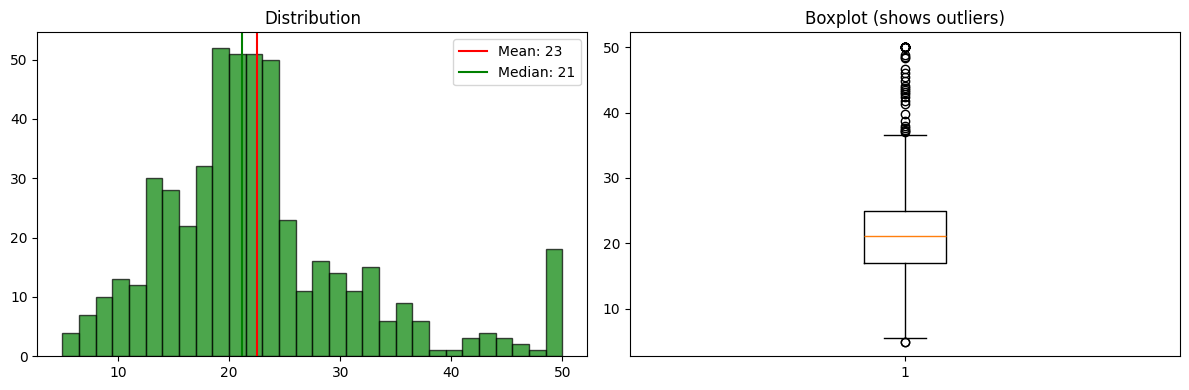

In [21]:
# Visualization distribution

fig, axes = plt.subplots(1, 2, figsize=(12,4))

# histogram
axes[0].hist(col, bins=30, color='green',
             alpha=0.7, edgecolor='black')
axes[0].axvline(col.mean(), color='red',
                label=f'Mean: {col.mean():.0f}')
axes[0].axvline(col.median(), color='green',
                label=f'Median: {col.median():.0f}')
axes[0].set_title('Distribution')
axes[0].legend()

# boxplot
axes[1].boxplot(col)
axes[1].set_title('Boxplot (shows outliers)')

plt.tight_layout()
plt.show()

Outlier detection

In [22]:
mean = col.mean()
std  = col.std()

# 3 standard deviation rule
lower = mean - 3*std
upper = mean + 3*std

outliers = df[(col < lower) | (col > upper)]
print(f"Total rows     : {len(df)}")
print(f"Outliers found : {len(outliers)}")
print(f"Normal range   : {lower:.0f} to {upper:.0f}")
print(outliers.head())

Total rows     : 506
Outliers found : 0
Normal range   : -5 to 50
Empty DataFrame
Columns: [crim, zn, indus, chas, nox, rm, age, dis, rad, tax, ptratio, b, lstat, medv]
Index: []


correlation matrix

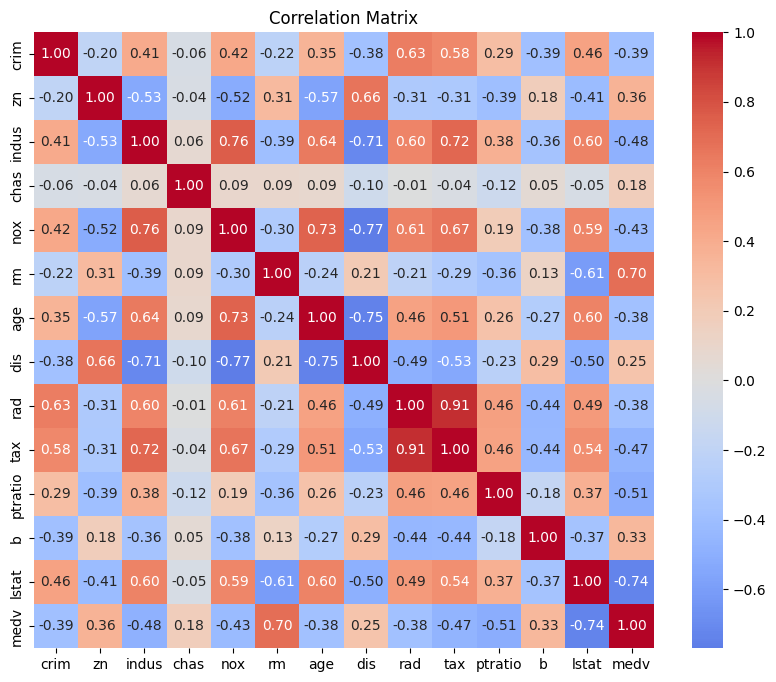


Correlation with price:
medv       1.000000
rm         0.695360
zn         0.360445
b          0.333461
dis        0.249929
chas       0.175260
age       -0.376955
rad       -0.381626
crim      -0.388305
nox       -0.427321
tax       -0.468536
indus     -0.483725
ptratio   -0.507787
lstat     -0.737663
Name: medv, dtype: float64


In [24]:
# correlation between all numeric columns
corr_matrix = df.corr(numeric_only=True)

# visualize as heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0)
plt.title('Correlation Matrix')
plt.show()

# which features correlate most with price?
print("\nCorrelation with price:")
print(corr_matrix['medv'].sort_values(
      ascending=False))

Standardization

In [ ]:
# Z-score standardization
# transforms data to mean=0, std=1
# critical before many ML algorithms

from sklearn.preprocessing import StandardScaler

# select numeric columns
numeric_cols = df.select_dtypes(
               include=[np.number]).columns

scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df[numeric_cols]),
    columns=numeric_cols
)

print("Before scaling:")
print(df[numeric_cols].describe().round(2))
print("\nAfter scaling:")
print(df_scaled.describe().round(2))
# mean ≈ 0, std ≈ 1 for all columns